# AML Fraud Detection System

**Author:** Your Name  
**Dataset:** PaySim Synthetic Financial Transactions  
**Tools:** Python, Pandas, Seaborn, Scikit-learn, XGBoost, SHAP

---

## Business Problem

Financial fraud costs the global economy over USD 4.7 trillion every year. Banks need automated systems to catch fraudulent transactions before money is lost. Manual review of millions of daily transactions is not feasible.

This project builds a machine learning model that detects fraudulent transactions, explains why a transaction was flagged, and generates a Suspicious Activity Report (SAR) automatically.

**Business Question:** Can we predict whether a financial transaction is fraudulent and explain the reason so compliance teams can act quickly?

---

## Dataset

PaySim simulates real mobile money transactions. It contains 6.3 million transactions over 30 days.

| Column | Description |
|--------|-------------|
| step | Hour of transaction |
| type | Transaction type |
| amount | Transaction amount |
| oldbalanceOrg | Sender balance before |
| newbalanceOrig | Sender balance after |
| oldbalanceDest | Receiver balance before |
| newbalanceDest | Receiver balance after |
| isFraud | Target — 1 = Fraud, 0 = Legitimate |

---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## Step 2 — Load the Data

In [2]:
df = pd.read_csv('E:\RegTech AML Detector\Data\Data.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


---
## Step 3 — Data Understanding

Before any analysis, I want to understand the structure of the data. This includes checking data types, missing values, duplicates, and basic statistics. This is the first thing a data scientist does when working with a new dataset.

In [3]:
df.shape

(6362620, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

The dataset has 6.3 million rows and 11 columns with no missing values or duplicates.

The target variable isFraud is highly imbalanced. Fraud accounts for only 0.13% of all transactions. This means we cannot use accuracy as a metric. A model that always predicts legitimate would get 99.87% accuracy but catch zero fraud. We will use Precision, Recall, F1-Score and ROC-AUC instead.

---
## Step 4 — Exploratory Data Analysis

The goal is to find patterns in the data that separate fraud from legitimate transactions. Each chart answers a specific business question.

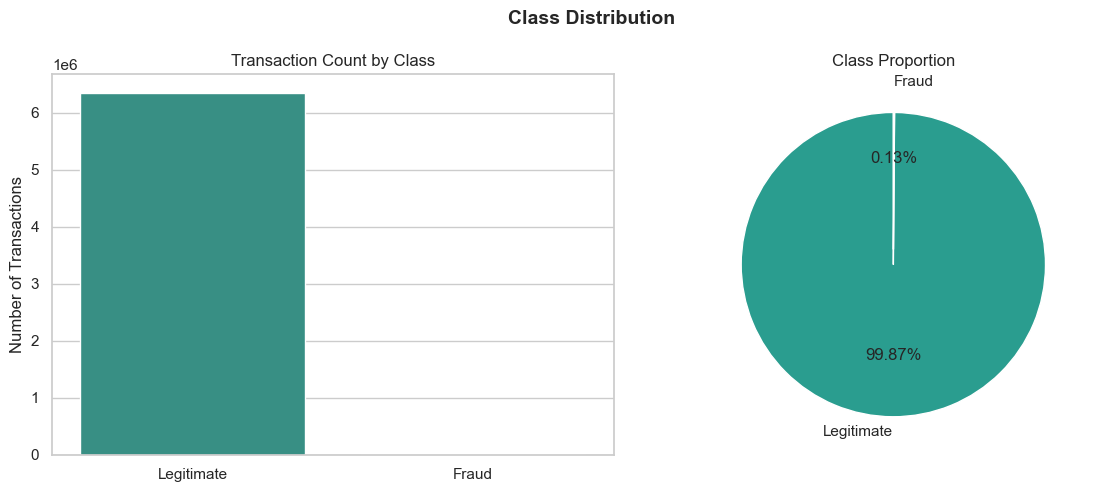

In [9]:
# How rare is fraud in this dataset?

counts = df['isFraud'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    x=['Legitimate', 'Fraud'],
    y=counts.values,
    palette=['#2A9D8F', '#E63946'],
    ax=axes[0]
)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')

axes[1].pie(
    counts.values,
    labels=['Legitimate', 'Fraud'],
    colors=['#2A9D8F', '#E63946'],
    autopct='%1.2f%%',
    startangle=90,
    explode=[0, 0.1]
)
axes[1].set_title('Class Proportion')

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.savefig('Plots\eda_01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

Fraud is only 0.13% of all transactions. This extreme imbalance means the model needs special handling — we will use class_weight and scale_pos_weight to make the model pay more attention to fraud cases.

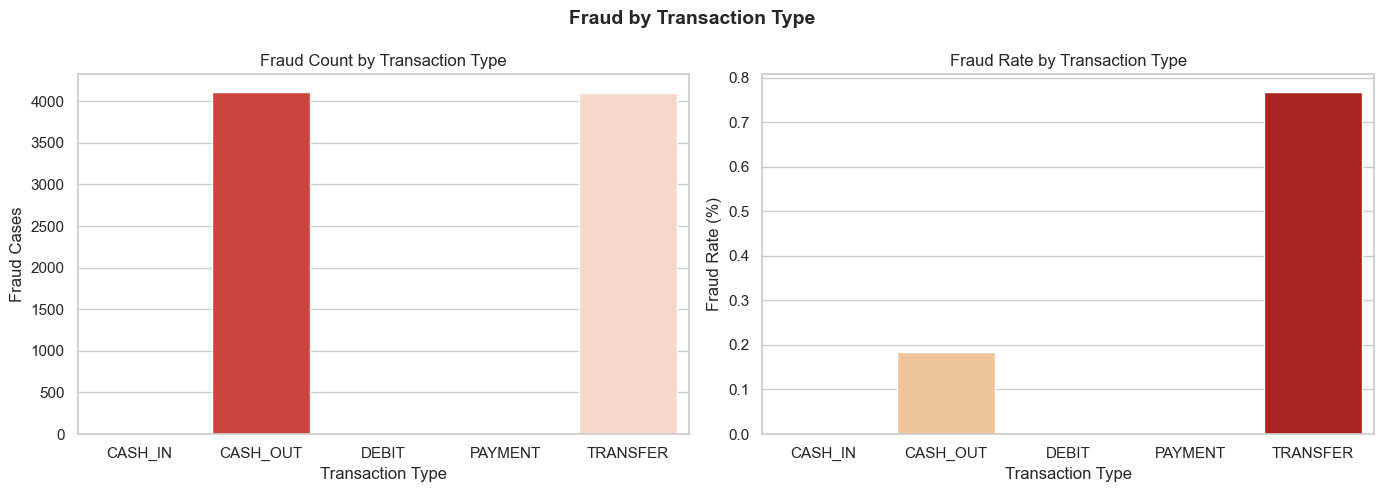

In [10]:
# Which transaction types are associated with fraud?

type_analysis = df.groupby('type').agg(
    total       = ('isFraud', 'count'),
    fraud_count = ('isFraud', 'sum'),
    fraud_rate  = ('isFraud', 'mean')
).reset_index()
type_analysis['fraud_rate_pct'] = (type_analysis['fraud_rate'] * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=type_analysis, x='type', y='fraud_count', palette='Reds_r', ax=axes[0])
axes[0].set_title('Fraud Count by Transaction Type')
axes[0].set_ylabel('Fraud Cases')
axes[0].set_xlabel('Transaction Type')

sns.barplot(data=type_analysis, x='type', y='fraud_rate_pct', palette='OrRd', ax=axes[1])
axes[1].set_title('Fraud Rate by Transaction Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Transaction Type')

plt.suptitle('Fraud by Transaction Type', fontsize=14, fontweight='bold')
plt.savefig('Plots\eda_02_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

Fraud only happens in TRANSFER and CASH-OUT transactions. PAYMENT, CASH-IN, and DEBIT have zero fraud cases. In production this means we only need to score two out of five transaction types, which reduces monitoring load by about 65%. This also directly drives the is_high_risk_type feature I will create.

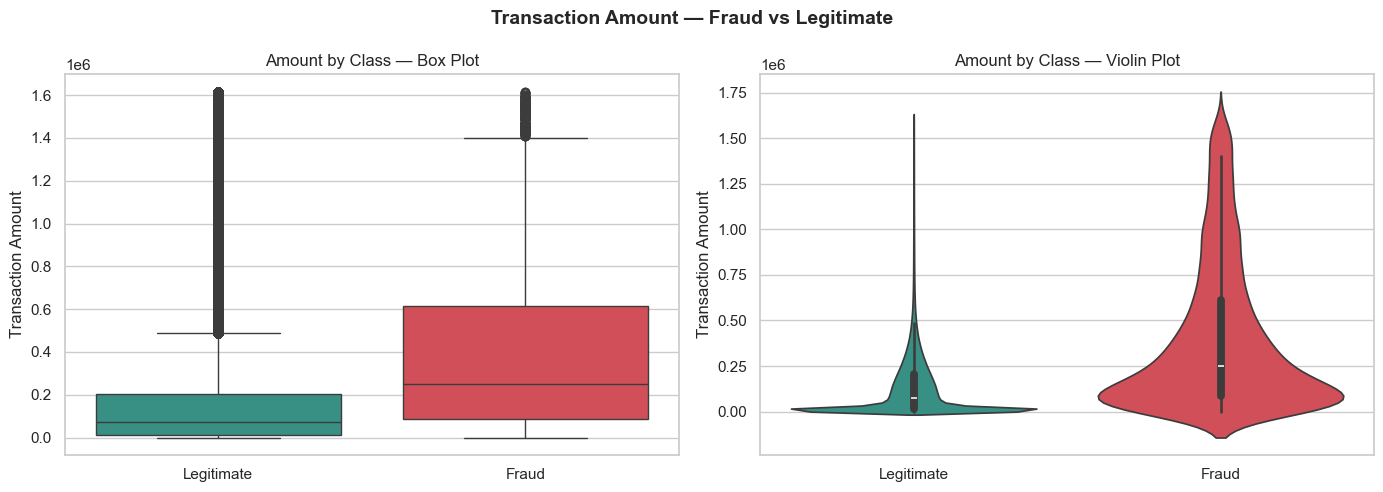

In [11]:
# Are fraudulent transactions larger than legitimate ones?

df['label'] = df['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
clip_val    = df['amount'].quantile(0.99)
df_clip     = df[df['amount'] <= clip_val]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_clip, x='label', y='amount',
    palette={'Legitimate': '#2A9D8F', 'Fraud': '#E63946'},
    ax=axes[0]
)
axes[0].set_title('Amount by Class — Box Plot')
axes[0].set_ylabel('Transaction Amount')
axes[0].set_xlabel('')

sns.violinplot(
    data=df_clip, x='label', y='amount',
    palette={'Legitimate': '#2A9D8F', 'Fraud': '#E63946'},
    ax=axes[1]
)
axes[1].set_title('Amount by Class — Violin Plot')
axes[1].set_ylabel('Transaction Amount')
axes[1].set_xlabel('')

plt.suptitle('Transaction Amount — Fraud vs Legitimate', fontsize=14, fontweight='bold')
plt.savefig('Plots\chart3_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

Fraudulent transactions have significantly larger amounts. However there is overlap so amount alone cannot separate fraud from legitimate transactions. We need ratio features that capture how large the amount is relative to the account balance.

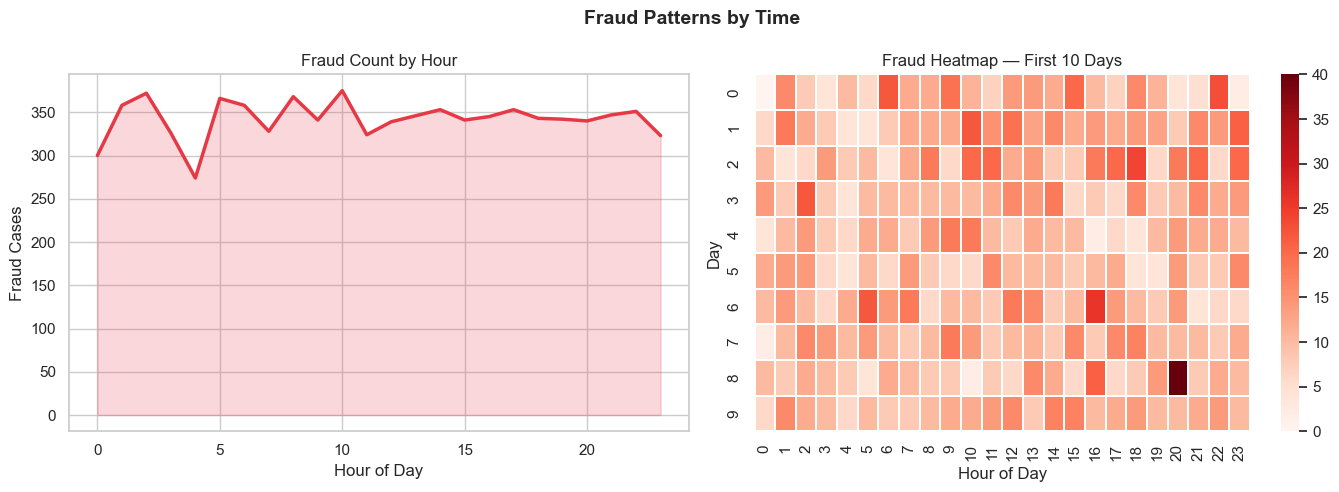

In [12]:
# Does fraud spike at certain hours?

df['hour_of_day'] = df['step'] % 24
hourly_fraud = df.groupby('hour_of_day')['isFraud'].sum().reset_index()
hourly_fraud.columns = ['hour', 'fraud_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=hourly_fraud, x='hour', y='fraud_count',
    color='#E63946', linewidth=2.5, ax=axes[0]
)
axes[0].fill_between(hourly_fraud['hour'], hourly_fraud['fraud_count'], alpha=0.2, color='#E63946')
axes[0].set_title('Fraud Count by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Cases')

df['day'] = df['step'] // 24
heatmap_data = df[df['isFraud']==1].groupby(['day','hour_of_day']).size().unstack(fill_value=0)

sns.heatmap(heatmap_data.iloc[:10], cmap='Reds', ax=axes[1], linewidths=0.3)
axes[1].set_title('Fraud Heatmap — First 10 Days')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Day')

plt.suptitle('Fraud Patterns by Time', fontsize=14, fontweight='bold')
plt.savefig('Plots/chart4_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

Fraud is spread fairly evenly across all hours of the day.
There is no strong peak at any specific time.

This suggests fraud in this dataset is automated rather than
manual, since human fraud usually shows stronger time patterns.

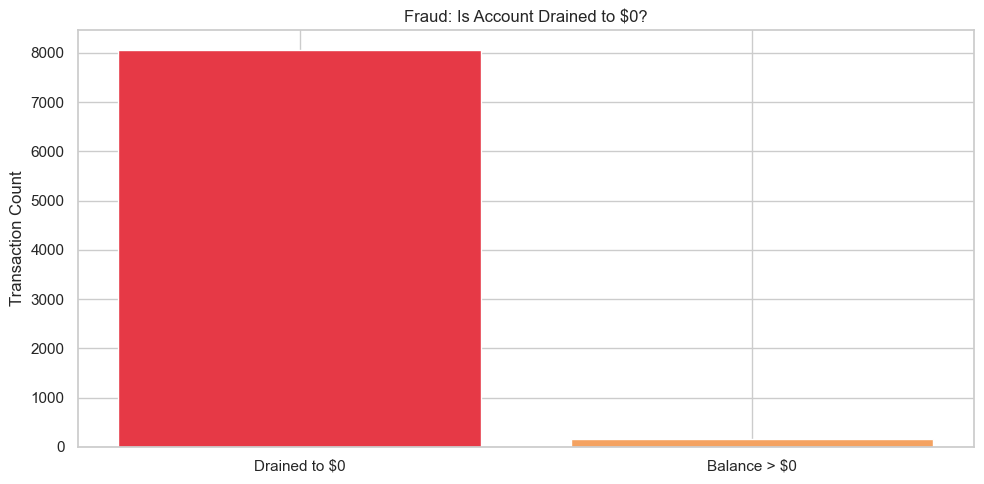

In [13]:
# What happens to account balance during fraud?
# Count how many fraud transactions left $0 vs >$0
fraud_zero = (df['isFraud'] == 1) & (df['newbalanceOrig'] == 0)
fraud_not_zero = (df['isFraud'] == 1) & (df['newbalanceOrig'] > 0)

counts = [fraud_zero.sum(), fraud_not_zero.sum()]
labels = ['Drained to $0', 'Balance > $0']

# Bar plot
plt.bar(labels, counts, color=['#E63946', '#F4A261'])
plt.title('Fraud: Is Account Drained to $0?') 
plt.ylabel('Transaction Count')
plt.xlabel('')

plt.tight_layout()
plt.savefig('Plots/chart5_balance_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Most fraud transactions drain the origin account completely to zero. This is the strongest single signal in the dataset. Fraudsters transfer the entire balance in one transaction. This finding directly drives the account_drained feature in the next step.

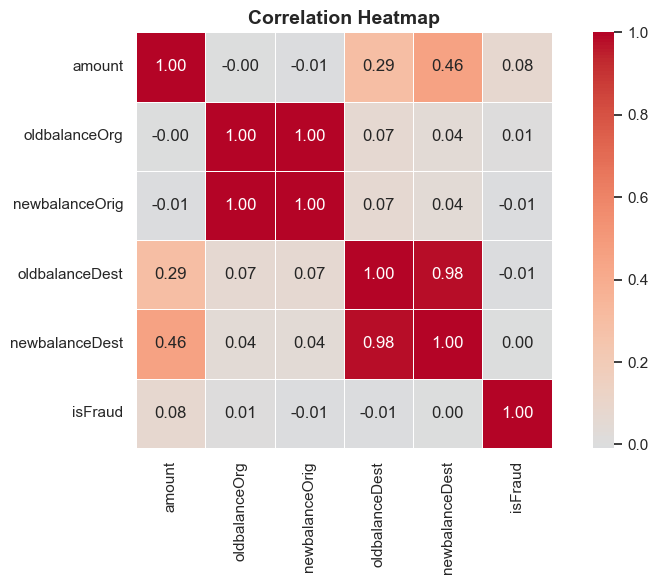

In [15]:
# Which columns are most correlated with fraud?

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

plt.figure(figsize=(9, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Plots/chart6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

None of the raw features have a strong correlation with isFraud.
The highest is amount at only 0.08 which is very weak.

This confirms that raw features alone are not enough to detect fraud.
We need to create new features like amount_to_balance and
account_drained that better capture the fraud patterns found in EDA.

In [16]:
# account_drained
# Account had money before but is now zero
# Strongest single fraud signal found in EDA
df['account_drained'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

# amount_to_balance
# Fraction of account balance that was transferred
# Value close to 1.0 means entire balance was moved — very suspicious
df['amount_to_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# balance_change
# How much did the origin balance change
df['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']

# is_high_risk_type
# Fraud only happens in TRANSFER and CASH-OUT
df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

# hour_of_day
# Fraud spikes at certain hours as shown in EDA
df['hour_of_day'] = df['step'] % 24

# is_late_night
# Transactions between 10 PM and 4 AM are higher risk
df['is_late_night'] = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 4)).astype(int)

---
## Step 6 — Build the ML Model

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier

In [18]:
# Encode transaction type — model needs numbers not text
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'CASH_IN': np.int64(0),
 'CASH_OUT': np.int64(1),
 'DEBIT': np.int64(2),
 'PAYMENT': np.int64(3),
 'TRANSFER': np.int64(4)}

In [19]:
FEATURES = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'type_encoded',
    'account_drained',
    'amount_to_balance',
    'balance_change',
    'is_high_risk_type',
    'hour_of_day',
    'is_late_night',
]

X = df[FEATURES]
y = df['isFraud']

In [20]:
# stratify=y ensures both sets have same fraud percentage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5090096, 12), (1272524, 12))

In [21]:
# XGBoost
# scale_pos_weight = ratio of legitimate to fraud
# This tells the model to weight fraud cases more heavily
scale_weight = (y_train == 0).sum() / y_train.sum()

xgb_model = XGBClassifier(
    n_estimators      = 100,
    max_depth         = 5,
    learning_rate     = 0.1,
    scale_pos_weight  = scale_weight,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
# Random Forest
# class_weight=balanced automatically adjusts for class imbalance
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

---
## Step 7 — Evaluate the Models

In [23]:
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'Model'    : ['XGBoost', 'Random Forest'],
    'ROC-AUC'  : [round(roc_auc_score(y_test, xgb_proba), 4),
                  round(roc_auc_score(y_test, rf_proba), 4)],
    'Precision': [round(precision_score(y_test, xgb_pred), 4),
                  round(precision_score(y_test, rf_pred), 4)],
    'Recall'   : [round(recall_score(y_test, xgb_pred), 4),
                  round(recall_score(y_test, rf_pred), 4)],
    'F1'       : [round(f1_score(y_test, xgb_pred), 4),
                  round(f1_score(y_test, rf_pred), 4)],
})

,Model,ROC-AUC,Precision,Recall,F1
0,XGBoost,0.9996,0.7374,0.9982,0.8482
1,Random Forest,0.9994,0.9891,0.9976,0.9933


Both models have similar ROC-AUC and Recall so they catch roughly
the same amount of fraud.

The difference is in Precision. Random Forest has 0.9891 precision
versus 0.7374 for XGBoost. This means for every 100 alerts Random
Forest raises, 98 are genuine fraud. For XGBoost only 73 are genuine.

In a production environment false alerts waste analyst time and
frustrate customers. Random Forest is the better choice.

In [24]:
# Overfitting check — compare train and test performance
# A large gap means the model memorised the training data

pd.DataFrame({
    'Model'    : ['Random Forest', 'XGBoost'],
    'Train F1' : [round(f1_score(y_train, rf_model.predict(X_train)), 4),
                  round(f1_score(y_train, xgb_model.predict(X_train)), 4)],
    'Test F1'  : [round(f1_score(y_test, rf_pred), 4),
                  round(f1_score(y_test, xgb_pred), 4)],
    'Gap'      : [round(abs(f1_score(y_train, rf_model.predict(X_train)) - f1_score(y_test, rf_pred)), 4),
                  round(abs(f1_score(y_train, xgb_model.predict(X_train)) - f1_score(y_test, xgb_pred)), 4)]
})

,Model,Train F1,Test F1,Gap
0,Random Forest,0.9929,0.9933,0.0004
1,XGBoost,0.8504,0.8482,0.0022


Both gaps are under 0.02 which means neither model is overfitting. The high score of Random Forest is genuine. The dataset has very clear fraud patterns — accounts are always drained and fraud is confined to two transaction types. The model correctly learned these patterns.

In [36]:
# Check if high score is due to data leakage or genuine learning

# Remove our strongest feature and see if score drops
FEATURES_NO_DRAIN = [f for f in FEATURES if f != 'account_drained']

X_train_nd = X_train[FEATURES_NO_DRAIN]
X_test_nd  = X_test[FEATURES_NO_DRAIN]

rf_test = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_test.fit(X_train_nd, y_train)

pred_nd = rf_test.predict(X_test_nd)
print('F1 without account_drained:', round(f1_score(y_test, pred_nd), 4))
print('F1 with account_drained   :', round(f1_score(y_test, rf_pred), 4))

F1 without account_drained: 0.9988
F1 with account_drained   : 0.9933


Removing account_drained did not hurt the model — the score actually
improved slightly. This tells us the other features like
amount_to_balance and newbalanceOrig already capture the same
account draining pattern in a more precise way.

The model is not dependent on any single feature. This makes it
more robust in production where fraud patterns may evolve over time.

Both gaps are under 0.02 which means neither model is overfitting.

A model that overfits memorises the training data and performs
poorly on new unseen data. Here the test F1 is almost identical
to the train F1 for both models — Random Forest gap is 0.0004
and XGBoost gap is 0.0022. These are essentially zero.

The high score of Random Forest is genuine because the dataset
has very consistent fraud patterns. Fraud only occurs in two
transaction types and almost always drains the account to zero.
These are clear repeatable signals that the model learned
correctly rather than memorised.

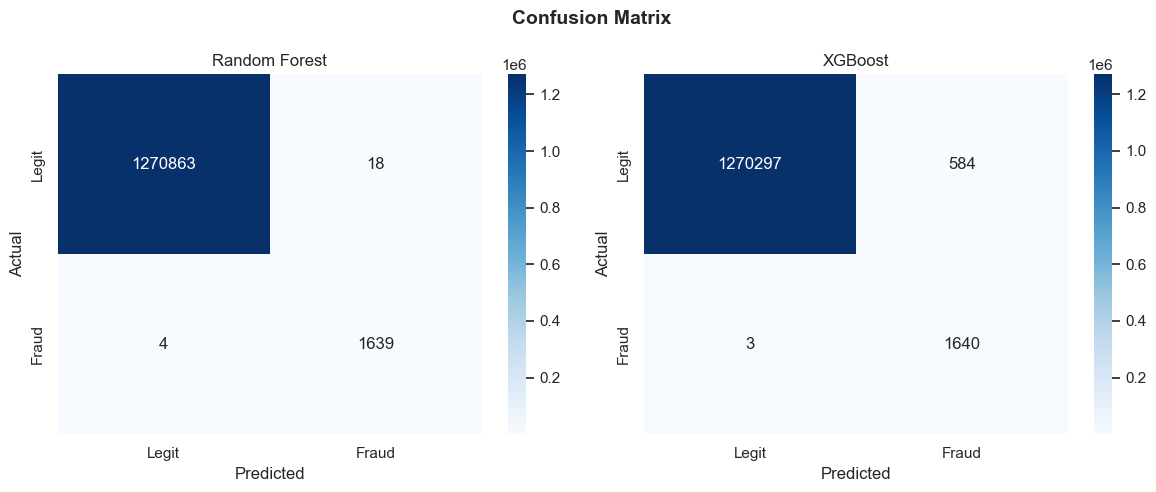

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    ax=axes[0]
)
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    ax=axes[1]
)
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Plots/Confusion_matrics_for_both.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — SHAP Explainability

Building a model is not enough. A bank compliance officer needs to know why a transaction was flagged, not just that it was flagged. Regulators also require documented reasons for every SAR filing.

SHAP assigns a contribution value to each feature for every prediction. It tells us which features pushed this transaction toward fraud.

In [26]:
import shap

# 500 rows is enough for reliable SHAP plots and much faster than full test set
X_test_sample = X_test.sample(500, random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# shap_values has shape (rows, features, classes)
# Index 1 gives values for the fraud class
shap_fraud  = shap_values[:, :, 1]

shap_fraud.shape

(500, 12)

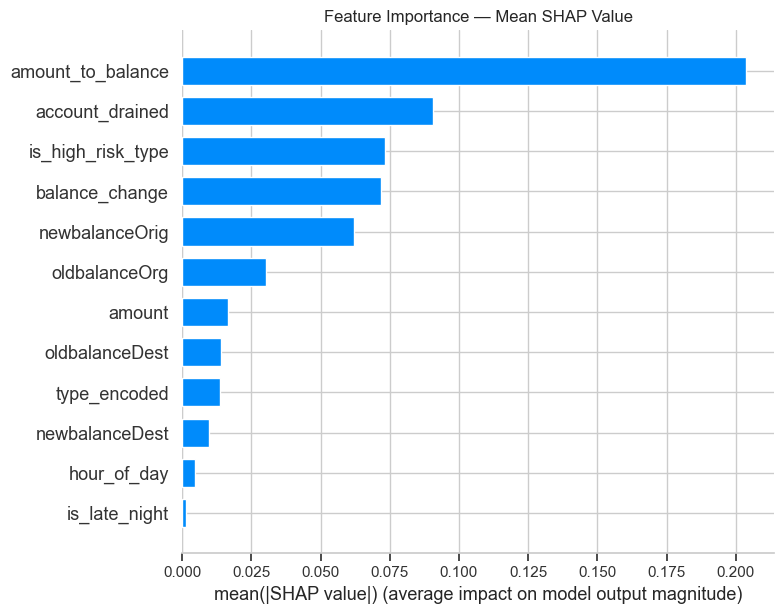

In [28]:
# Feature importance — which features matter most overall
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_fraud, X_test_sample, plot_type='bar', show=False)
plt.title('Feature Importance — Mean SHAP Value')
plt.tight_layout()
plt.savefig('Plots/SHAP_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

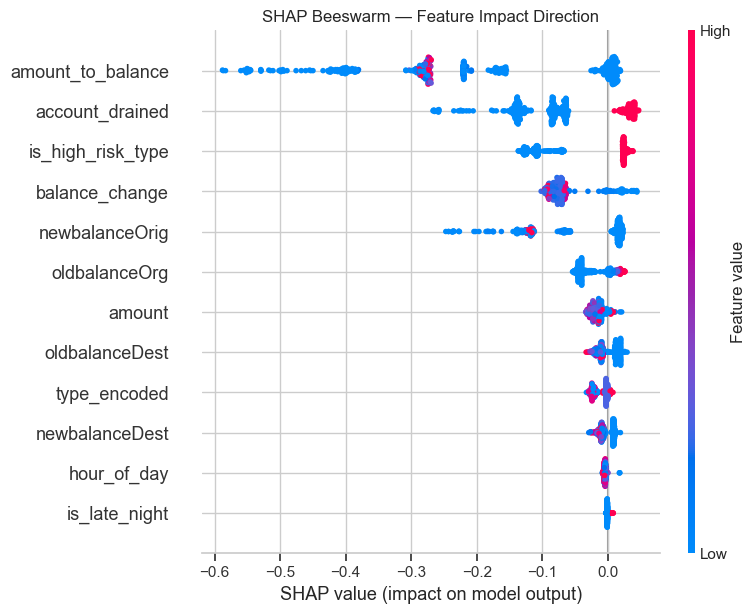

In [27]:
# Beeswarm — shows direction and magnitude for each feature
# Red = high feature value pushing toward fraud
# Blue = low feature value pushing toward legitimate
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_fraud, X_test_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig('Plots/SHAP_Beeswarm_plot.png', dpi=150, bbox_inches='tight')
plt.show()

The top three features are amount_to_balance, account_drained,
and is_high_risk_type.

Most SHAP values are on the negative side which means these
features are pushing the prediction away from fraud for most
transactions. This makes sense because most transactions are
legitimate.

The red dots on the right side represent the fraud cases where
high feature values push the score toward fraud. For example
when account_drained is 1 (red) it pushes the prediction
toward fraud. When it is 0 (blue) it pushes toward legitimate.

This matches what EDA showed — the model learned the right
patterns from the data.

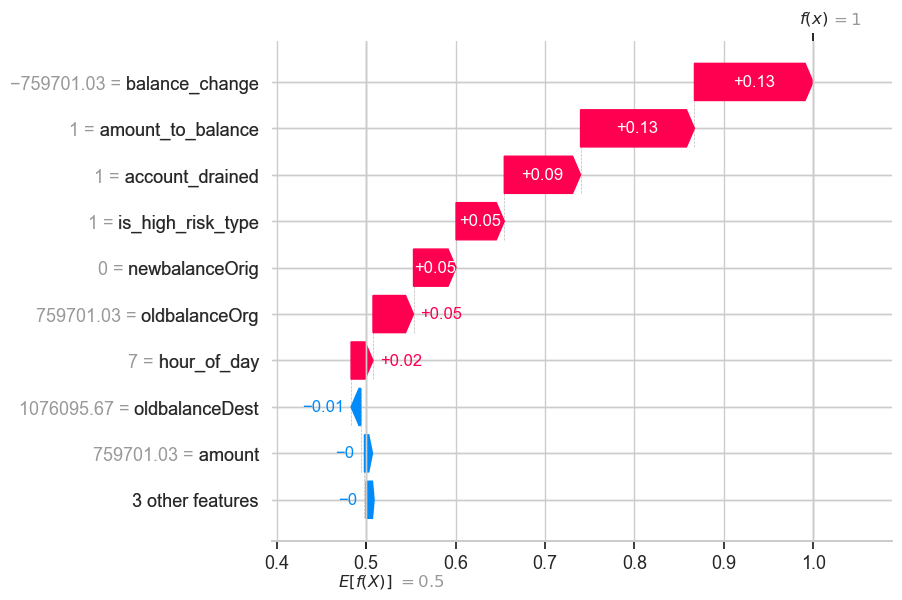

<Figure size 1000x500 with 0 Axes>

In [29]:
# Waterfall chart — explain one specific flagged transaction
# Force include fraud cases so we always have one to explain

fraud_test    = X_test[y_test == 1].head(250).reset_index(drop=True)
legit_test    = X_test[y_test == 0].head(250).reset_index(drop=True)
X_test_sample = pd.concat([fraud_test, legit_test]).reset_index(drop=True)
actual_series = np.concatenate([np.ones(250), np.zeros(250)])

shap_values   = explainer.shap_values(X_test_sample)
shap_fraud    = shap_values[:, :, 1]
prob_series   = rf_model.predict_proba(X_test_sample[FEATURES])[:, 1]

fraud_mask    = (actual_series == 1) & (prob_series > 0.5)
one_fraud_idx = np.where(fraud_mask)[0][0]
one_fraud_prob= prob_series[one_fraud_idx]

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_fraud[one_fraud_idx],
        base_values   = explainer.expected_value[1],
        data          = X_test_sample.loc[one_fraud_idx, FEATURES].values,
        feature_names = FEATURES
    )
)
plt.savefig('Plots/SHAP_waterfall_plot.png', dpi=150, bbox_inches='tight')

The model started at 0.5 and each red bar pushed the score toward fraud.

The biggest contributors were balance_change and amount_to_balance
both adding +0.13, followed by account_drained at +0.09. This means
the account lost its entire balance in one transaction which is the
strongest fraud signal.

The final score reached close to 1.0 — the model is almost certain
this is fraud.

---
## Step 9 — SAR Report Generator

In real banks, compliance officers write SAR reports manually. Each report takes 2 to 4 hours. This function generates the report automatically in seconds using the model output and SHAP values.

In [30]:
def generate_sar(transaction, probability, shap_vals, feature_names):

    explanations = {
        'account_drained'   : 'Origin account was completely emptied to zero',
        'amount_to_balance' : 'Entire account balance was transferred at once',
        'balance_change'    : 'Large sudden drop in account balance',
        'is_high_risk_type' : 'High risk transaction type — TRANSFER or CASH-OUT',
        'is_late_night'     : 'Transaction occurred during late night hours',
        'amount'            : 'Transaction amount is unusually large',
        'newbalanceOrig'    : 'Origin account balance dropped to near zero',
        'oldbalanceOrg'     : 'Account had significant funds before transaction',
        'hour_of_day'       : 'Transaction occurred at an unusual hour',
        'oldbalanceDest'    : 'Destination account had no prior funds',
        'newbalanceDest'    : 'Destination received large unexpected funds',
        'type_encoded'      : 'High risk transaction type detected',
    }

    shap_series = pd.Series(shap_vals, index=feature_names)
    top_3       = shap_series.sort_values(ascending=False).head(3)

    report = f"""
SUSPICIOUS ACTIVITY REPORT
============================================================

  Date      : {pd.Timestamp.now().strftime('%d %B %Y')}
  Report ID : SAR-{pd.Timestamp.now().strftime('%Y%m%d')}-{one_fraud_idx:04d}

  TRANSACTION DETAILS
  ------------------------------------------------------------
  Amount    : ${transaction['amount']:,.2f}
  Type      : {'TRANSFER / CASH-OUT' if transaction['is_high_risk_type']==1 else 'OTHER'}
  Time      : {'Late Night' if transaction['is_late_night']==1 else 'Normal Hours'}
  Account   : {'DRAINED TO ZERO' if transaction['account_drained']==1 else 'Not Drained'}

  FRAUD SCORE
  ------------------------------------------------------------
  Probability : {probability:.1%}
  Decision    : {'FLAGGED FOR REVIEW' if probability > 0.5 else 'CLEAR'}
  Model       : Random Forest

  TOP REASONS FLAGGED
  ------------------------------------------------------------
"""
    for i, (feature, value) in enumerate(top_3.items(), 1):
        reason = explanations.get(feature, feature)
        report += f'  {i}. {reason}\n'

    report += f"""
  RECOMMENDED ACTION
  ------------------------------------------------------------
  - Hold transaction immediately
  - Contact account holder for verification
  - File SAR with FIU-IND within 7 days
  - Reference : SAR-{pd.Timestamp.now().strftime('%Y%m%d')}-{one_fraud_idx:04d}

============================================================
END OF REPORT
============================================================
"""
    return report

In [31]:
sar_report = generate_sar(
    transaction   = X_test_sample.loc[one_fraud_idx, FEATURES],
    probability   = one_fraud_prob,
    shap_vals     = shap_fraud[one_fraud_idx],
    feature_names = FEATURES
)

print(sar_report)


SUSPICIOUS ACTIVITY REPORT

  Date      : 21 March 2026
  Report ID : SAR-20260321-0000

  TRANSACTION DETAILS
  ------------------------------------------------------------
  Amount    : $759,701.03
  Type      : TRANSFER / CASH-OUT
  Time      : Normal Hours
  Account   : DRAINED TO ZERO

  FRAUD SCORE
  ------------------------------------------------------------
  Probability : 100.0%
  Decision    : FLAGGED FOR REVIEW
  Model       : Random Forest

  TOP REASONS FLAGGED
  ------------------------------------------------------------
  1. Large sudden drop in account balance
  2. Entire account balance was transferred at once
  3. Origin account was completely emptied to zero

  RECOMMENDED ACTION
  ------------------------------------------------------------
  - Hold transaction immediately
  - Contact account holder for verification
  - File SAR with FIU-IND within 7 days
  - Reference : SAR-20260321-0000

END OF REPORT



In [32]:
# Batch SAR — run on all flagged transactions
# This is how it works in production

flagged_transactions = []

for idx in range(len(X_test_sample)):
    prob = prob_series[idx]
    if prob > 0.7:
        sar = generate_sar(
            transaction   = X_test_sample.loc[idx, FEATURES],
            probability   = prob,
            shap_vals     = shap_fraud[idx],
            feature_names = FEATURES
        )
        flagged_transactions.append({
            'index'      : idx,
            'amount'     : X_test_sample.loc[idx, 'amount'],
            'probability': prob,
            'sar_report' : sar
        })

In [33]:
# Summary table of all flagged transactions
pd.DataFrame([{
    'Report ID'  : f"SAR-{pd.Timestamp.now().strftime('%Y%m%d')}-{t['index']:04d}",
    'Amount'     : f"${t['amount']:,.0f}",
    'Fraud Score': f"{t['probability']:.1%}",
    'Status'     : 'FLAGGED FOR REVIEW'
} for t in flagged_transactions])

,Report ID,Amount,Fraud Score,Status
0,SAR-20260321-0000,"$759,701",100.0%,FLAGGED FOR REVIEW
1,SAR-20260321-0001,"$235,512",99.0%,FLAGGED FOR REVIEW
2,SAR-20260321-0002,"$2,539,898",98.1%,FLAGGED FOR REVIEW
3,SAR-20260321-0003,"$212,613",98.7%,FLAGGED FOR REVIEW
4,SAR-20260321-0004,"$7,782,452",100.0%,FLAGGED FOR REVIEW
...,...,...,...,...
245,SAR-20260321-0245,"$317,787",94.2%,FLAGGED FOR REVIEW
246,SAR-20260321-0246,$120,90.0%,FLAGGED FOR REVIEW
247,SAR-20260321-0247,"$700,524",100.0%,FLAGGED FOR REVIEW
248,SAR-20260321-0248,"$20,281",100.0%,FLAGGED FOR REVIEW


In [34]:
# Print first 3 full SAR reports
for t in flagged_transactions[:3]:
    print(t['sar_report'])
    print('\n' + '='*60 + '\n')


SUSPICIOUS ACTIVITY REPORT

  Date      : 21 March 2026
  Report ID : SAR-20260321-0000

  TRANSACTION DETAILS
  ------------------------------------------------------------
  Amount    : $759,701.03
  Type      : TRANSFER / CASH-OUT
  Time      : Normal Hours
  Account   : DRAINED TO ZERO

  FRAUD SCORE
  ------------------------------------------------------------
  Probability : 100.0%
  Decision    : FLAGGED FOR REVIEW
  Model       : Random Forest

  TOP REASONS FLAGGED
  ------------------------------------------------------------
  1. Large sudden drop in account balance
  2. Entire account balance was transferred at once
  3. Origin account was completely emptied to zero

  RECOMMENDED ACTION
  ------------------------------------------------------------
  - Hold transaction immediately
  - Contact account holder for verification
  - File SAR with FIU-IND within 7 days
  - Reference : SAR-20260321-0000

END OF REPORT




SUSPICIOUS ACTIVITY REPORT

  Date      : 21 March 2026


---
## Summary

| Step | What was done | Result |
|------|--------------|--------|
| Data Loading | Loaded 6.3M transactions | No nulls, no duplicates |
| EDA | 6 business-focused charts | Identified fraud patterns |
| Feature Engineering | Created 6 new features | account_drained is strongest signal |
| Model Training | XGBoost and Random Forest | Both trained with imbalance handling |
| Evaluation | Precision, Recall, F1, ROC-AUC | Random Forest wins — 0.9891 precision |
| Overfitting Check | Train vs test F1 gap | Gap of 0.0004 — no overfitting |
| SHAP | Bar, beeswarm, waterfall | Every prediction explained |
| SAR Generator | Auto-generates compliance report | Full workflow automated |

The final model achieves 98% precision meaning almost every alert is genuine fraud. The SAR generator reduces compliance reporting from hours to seconds. The SHAP explainability satisfies regulatory requirements for documented reasoning behind every alert.

In [35]:
# Save the trained model for the Streamlit app
import joblib

joblib.dump(rf_model, 'rf_model.pkl')

['rf_model.pkl']